# One-hot encoding y red neuronal

Este notebook usa `firms_spain_final.csv` para preparar variables categóricas con one-hot encoding y entrenar una red neuronal de clasificación mediante `MLPClassifier` de scikit-learn. Por defecto, predice la columna `type`, que contiene la clase de la detección. Puedes cambiar `TARGET` en la primera celda si tu objetivo es otra variable categórica.

Se separan los datos en entrenamiento y prueba antes de ajustar el preprocesamiento. Las variables categóricas se imputan y codifican; las numéricas se imputan y estandarizan. La métrica en el conjunto de prueba ofrece una primera evaluación, no una validación operacional ni causal.

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, accuracy_score, balanced_accuracy_score

csv_path = Path.home() / 'Desktop' / 'wildfires-project-development' / 'data' / 'processed' / 'enriched' / 'firms_spain_final.csv'
if not csv_path.exists():
    raise FileNotFoundError(f'No se encontró el CSV: {csv_path}')
df = pd.read_csv(csv_path, low_memory=False)
TARGET = 'type'  # Cambia este valor si quieres predecir otra variable categórica.
if TARGET not in df.columns:
    raise ValueError(f'No existe la variable objetivo {TARGET!r}.')
print(f'Filas: {len(df):,}; columnas: {df.shape[1]}')
print('Distribución de la variable objetivo:')
display(df[TARGET].value_counts(dropna=False).rename_axis(TARGET).to_frame('n'))

Filas: 35,284; columnas: 50
Distribución de la variable objetivo:


,n
type,
0,30931
2,4312
3,41


## Preparar variables

Se excluyen `acq_date` y `acq_time` como texto/códigos sin transformar; para conservar parte de la fecha se derivan mes y día del año. Los campos CLC y otros códigos nominales se tratan como categorías, aunque estén guardados como números.

In [2]:
data = df.dropna(subset=[TARGET]).copy()

if 'acq_date' in data.columns:
    dates = pd.to_datetime(data['acq_date'], errors='coerce')
    data['acq_month'] = dates.dt.month
    data['acq_day_of_year'] = dates.dt.dayofyear

drop_cols = [c for c in ['acq_date', 'acq_time'] if c in data.columns]
X = data.drop(columns=[TARGET] + drop_cols)
y = data[TARGET].astype(str)

# Códigos CLC y etiquetas/códigos que representan categorías, no magnitudes.
explicit_categorical = {c for c in X.columns if c.lower().startswith('clc_')}
explicit_categorical.update(c for c in ['satellite', 'instrument', 'daynight', 'country', 'ccaa', 'confidence_cat', 'confidence_og_cat'] if c in X.columns)
explicit_categorical.update(c for c in X.columns if pd.api.types.is_bool_dtype(X[c]))
categorical_cols = sorted(set(X.select_dtypes(include=['object', 'category']).columns) | explicit_categorical)
numeric_cols = [c for c in X.select_dtypes(include=[np.number]).columns if c not in categorical_cols]

if not numeric_cols and not categorical_cols:
    raise ValueError('No hay variables predictoras disponibles después de excluir el objetivo.')
print(f'Predictores numéricos ({len(numeric_cols)}): {numeric_cols}')
print(f'Predictores categóricos ({len(categorical_cols)}): {categorical_cols}')
display(pd.DataFrame({'tipo': ['numérica'] * len(numeric_cols) + ['categórica'] * len(categorical_cols),
                      'columna': numeric_cols + categorical_cols}))

Predictores numéricos (30): ['latitude', 'longitude', 'brightness', 'scan', 'track', 'version', 'brightness_ir', 'frp', 'year', 'confidence_og_num', 'confidence_num', 'temperature_2m', 'precipitation', 'surface_pressure', 'relative_humidity_2m', 'wind_speed_10m', 'wind_direction_10m', 'wind_gusts_10m', 'rain', 'et0_fao_evapotranspiration', 'shortwave_radiation', 'boundary_layer_height', 'is_day', 'vapour_pressure_deficit', 'soil_moisture_0_to_7cm', 'soil_moisture_7_to_28cm', 'sum_prevention', 'sum_extinction', 'acq_month', 'acq_day_of_year']
Predictores categóricos (19): ['ccaa', 'clc_class', 'clc_class_E', 'clc_class_N', 'clc_class_NE', 'clc_class_NW', 'clc_class_S', 'clc_class_SE', 'clc_class_SW', 'clc_class_W', 'clc_uniform_surroundings', 'confidence', 'confidence_cat', 'confidence_og_cat', 'country', 'daynight', 'instrument', 'satellite', 'sensor']


,tipo,columna
0,numérica,latitude
1,numérica,longitude
2,numérica,brightness
3,numérica,scan
4,numérica,track
5,numérica,version
6,numérica,brightness_ir
7,numérica,frp
8,numérica,year
9,numérica,confidence_og_num


## Separación, one-hot encoding y entrenamiento

Las etiquetas de clase se codifican como enteros para el clasificador. El one-hot encoding de los predictores categóricos ocurre dentro del pipeline y se ajusta únicamente con el conjunto de entrenamiento, lo que evita que el preprocesamiento aprenda categorías desde el conjunto de prueba.

In [3]:
class_counts = y.value_counts()
if class_counts.min() < 2:
    raise ValueError('Cada clase necesita al menos 2 filas para crear una partición estratificada. Revisa la distribución del objetivo.')

X_train, X_test, y_train_text, y_test_text = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
label_encoder = LabelEncoder()
y_train = label_encoder.fit_transform(y_train_text)
y_test = label_encoder.transform(y_test_text)

numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])
try:
    one_hot = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
except TypeError:  # compatibilidad con versiones anteriores de scikit-learn
    one_hot = OneHotEncoder(handle_unknown='ignore', sparse=False)
categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', one_hot)
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_pipeline, numeric_cols),
    ('cat', categorical_pipeline, categorical_cols)
], remainder='drop')

model = Pipeline([
    ('preprocessor', preprocessor),
    ('neural_network', MLPClassifier(
        hidden_layer_sizes=(64, 32), activation='relu', solver='adam',
        alpha=0.0001, batch_size='auto', learning_rate_init=0.001,
        max_iter=100, early_stopping=True, validation_fraction=0.1,
        n_iter_no_change=10, random_state=42
    ))
])
model.fit(X_train, y_train)
print('Forma después del preprocesamiento:', model.named_steps['preprocessor'].transform(X_train).shape)
print('Iteraciones de entrenamiento:', model.named_steps['neural_network'].n_iter_)
print('¿Convergió según scikit-learn?:', not model.named_steps['neural_network']._no_improvement_count > 10)

Forma después del preprocesamiento: (28227, 254)
Iteraciones de entrenamiento: 18
¿Convergió según scikit-learn?: False


Accuracy: 0.960
Balanced accuracy: 0.693

Informe por clase:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98      6186
           2       0.83      0.85      0.84       863
           3       0.67      0.25      0.36         8

    accuracy                           0.96      7057
   macro avg       0.83      0.69      0.73      7057
weighted avg       0.96      0.96      0.96      7057



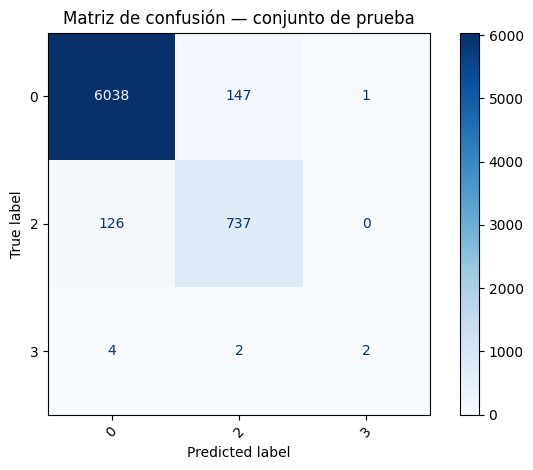

In [4]:
y_pred = model.predict(X_test)
print(f'Accuracy: {accuracy_score(y_test, y_pred):.3f}')
print(f'Balanced accuracy: {balanced_accuracy_score(y_test, y_pred):.3f}')
print('\nInforme por clase:')
print(classification_report(y_test, y_pred, labels=np.arange(len(label_encoder.classes_)), target_names=label_encoder.classes_, zero_division=0))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    labels=np.arange(len(label_encoder.classes_)),
    display_labels=label_encoder.classes_,
    cmap='Blues', xticks_rotation=45, values_format='d'
)
plt.title('Matriz de confusión — conjunto de prueba')
plt.tight_layout()
plt.show()